DATASET CREATION
Features (x1, x2):
[[1. 1.]
 [2. 1.]
 [3. 3.]
 [4. 5.]
 [5. 5.]]
Targets (y):
[0. 1. 5. 1. 0.]

MODEL TRAINING
--- Starting K-Means Initialization ---
K-Means Iter 1: Centroid Shift = 1.740051
  Centers: [[1.5      1.      ]
 [4.       4.333333]]
K-Means Iter 2: Centroid Shift = 0.000000
  Centers: [[1.5      1.      ]
 [4.       4.333333]]
K-Means Converged.

--- Initialization Complete ---
Centers (c): [[1.5      1.      ]
 [4.       4.333333]]
Widths (sigma): [2.083333 2.083333]
Weights (w): [ 0.248357 -0.069132]
Bias (b): 0.0

--- Starting Supervised Training (Gradient Descent) ---

Epoch 0:
  Loss: 5.208982
  Predictions: [ 0.234491  0.229182  0.070688 -0.046544 -0.048947]
  Errors: [ 0.234491 -0.770818 -4.929312 -1.046544 -0.048947]
  Grad Weights: [-1.201196 -1.890895]
  Grad Bias: -5.248904
  Grad Widths: [-0.186485  0.036767]
  Grad Centers: [[-0.098321 -0.117392]
 [-0.023822 -0.028388]]
  Updated Centers: [[1.509832 1.011739]
 [4.002382 4.336172]]
  Updated W

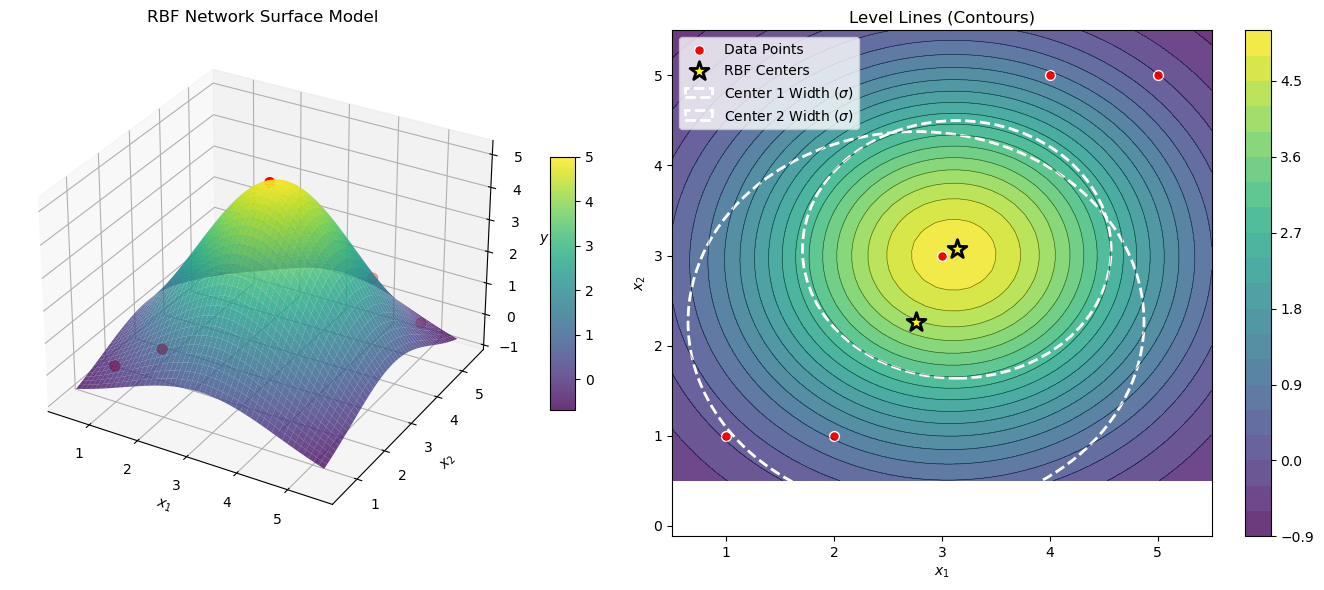


FINAL EVALUATION
Sample    Actual    Predicted Error     
----------------------------------------
0         0.0000    0.0441    0.0441    
1         1.0000    0.9698    0.0302    
2         5.0000    4.9940    0.0060    
3         1.0000    0.9837    0.0163    
4         0.0000    0.0161    0.0161    

Final Model Equation Approximation:
y = -1.1231 + 
    0.9513 * exp(-((x1-2.7602)^2 + (x2-2.2630)^2) / (2*2.1128^2)) + 
    5.2581 * exp(-((x1-3.1380)^2 + (x2-3.0679)^2) / (2*1.4303^2)) + 


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

class KMeansScratch:
    """K-Means clustering algorithm implemented from scratch using numpy."""
    def __init__(self, n_clusters=2, max_iters=100):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.centroids = None
    
    def _euclidean_distance(self, X, centroids):
        """Compute Euclidean distance between X and centroids."""
        # X: (N, 2), Centroids: (K, 2)
        # Returns: (N, K)
        distances = np.zeros((X.shape[0], centroids.shape[0]))
        for k in range(centroids.shape[0]):
            diff = X - centroids[k]
            distances[:, k] = np.sqrt(np.sum(diff ** 2, axis=1))
        return distances
    
    def fit(self, X):
        """Fit K-Means to data X."""
        print("--- Starting K-Means Initialization ---")
        # Initialize centroids randomly from data points
        indices = np.array([0,2])#np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[indices].copy()
        
        for i in range(self.max_iters):
            # 1. Assign clusters
            distances = self._euclidean_distance(X, self.centroids)
            labels = np.argmin(distances, axis=1)
            
            # 2. Update centroids
            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                cluster_points = X[labels == k]
                if len(cluster_points) > 0:
                    new_centroids[k] = cluster_points.mean(axis=0)
                else:
                    new_centroids[k] = self.centroids[k]
            
            # Check convergence
            shift = np.sqrt(np.sum((new_centroids - self.centroids) ** 2))
            self.centroids = new_centroids
            
            print(f"K-Means Iter {i+1}: Centroid Shift = {shift:.6f}")
            print(f"  Centers: {self.centroids}")
            
            if shift < 1e-4:
                print("K-Means Converged.")
                break
        return self.centroids

class RBFNetwork:
    """RBF Neural Network with Gradient Descent for all parameters."""
    def __init__(self, n_hidden=2, lr=0.01, epochs=500):
        self.n_hidden = n_hidden
        self.lr = lr
        self.epochs = epochs
        self.centers = None
        self.widths = None
        self.weights = None
        self.bias = None
        self.history = []
    
    def _gaussian(self, X, center, width):
        """Calculate Gaussian RBF activation."""
        diff = X - center
        dist_sq = np.sum(diff ** 2, axis=1)
        return np.exp(-dist_sq / (2 * width ** 2))
    
    def initialize(self, X):
        """Initialize centers using K-Means, widths using heuristic, weights randomly."""
        kmeans = KMeansScratch(n_clusters=self.n_hidden)
        self.centers = kmeans.fit(X)
        
        # Initialize widths: average distance between centers
        dist_between_centers = np.sqrt(np.sum((self.centers[0] - self.centers[1])**2))
        self.widths = np.array([dist_between_centers, dist_between_centers]) * 0.5
        self.widths = np.maximum(self.widths, 0.1) # Prevent division by zero
        
        # Initialize weights and bias
        self.weights = np.random.randn(self.n_hidden) * 0.5
        self.bias = 0.0
        
        print("\n--- Initialization Complete ---")
        print(f"Centers (c): {self.centers}")
        print(f"Widths (sigma): {self.widths}")
        print(f"Weights (w): {self.weights}")
        print(f"Bias (b): {self.bias}")

    def forward(self, X):
        """Forward pass."""
        activations = np.zeros((X.shape[0], self.n_hidden))
        for j in range(self.n_hidden):
            activations[:, j] = self._gaussian(X, self.centers[j], self.widths[j])
        output = np.dot(activations, self.weights) + self.bias
        return output, activations
    
    def train(self, X, y):
        """Train using Gradient Descent."""
        print("\n--- Starting Supervised Training (Gradient Descent) ---")
        N = X.shape[0]
        
        for epoch in range(self.epochs):
            # 1. Forward Pass
            y_pred, activations = self.forward(X)
            error = y_pred - y
            loss = np.mean(error ** 2)
            
            # Record history
            if epoch < 5 or epoch % 100 == 0 or epoch == self.epochs - 1:
                self.history.append({
                    'epoch': epoch,
                    'loss': loss,
                    'centers': self.centers.copy(),
                    'widths': self.widths.copy(),
                    'weights': self.weights.copy(),
                    'bias': self.bias
                })
            
            # 2. Backward Pass (Gradients)
            grad_w = np.zeros(self.n_hidden)
            grad_b = 0.0
            grad_sigma = np.zeros(self.n_hidden)
            grad_c = np.zeros_like(self.centers)
            
            # Calculate gradients summing over all samples
            for i in range(N):
                for j in range(self.n_hidden):
                    phi = activations[i, j]
                    diff = X[i] - self.centers[j]
                    dist_sq = np.sum(diff ** 2)
                    
                    # Gradient for weights
                    grad_w[j] += (2.0 / N) * error[i] * phi
                    
                    # Gradient for bias
                    grad_b += (2.0 / N) * error[i]
                    
                    # Gradient for widths (sigma)
                    # d/d_sigma exp(-d^2 / 2s^2) = exp(...) * (d^2 / s^3)
                    if self.widths[j] > 1e-5:
                        grad_sigma[j] += (2.0 / N) * error[i] * self.weights[j] * phi * (dist_sq / (self.widths[j] ** 3))
                    
                    # Gradient for centers
                    # d/d_c exp(-||x-c||^2 / 2s^2) = exp(...) * (x-c) / s^2
                    if self.widths[j] > 1e-5:
                        grad_c[j] += (2.0 / N) * error[i] * self.weights[j] * phi * (diff / (self.widths[j] ** 2))
            
            # 3. Update Parameters
            self.weights -= self.lr * grad_w
            self.bias -= self.lr * grad_b
            self.widths -= self.lr * grad_sigma
            self.centers -= self.lr * grad_c
            
            # Constraint: widths must be positive
            self.widths = np.maximum(self.widths, 0.01)
            
            # Detailed Logging for first 5 epochs
            if epoch < 5:
                print(f"\nEpoch {epoch}:")
                print(f"  Loss: {loss:.6f}")
                print(f"  Predictions: {y_pred}")
                print(f"  Errors: {error}")
                print(f"  Grad Weights: {grad_w}")
                print(f"  Grad Bias: {grad_b:.6f}")
                print(f"  Grad Widths: {grad_sigma}")
                print(f"  Grad Centers: {grad_c}")
                print(f"  Updated Centers: {self.centers}")
                print(f"  Updated Widths: {self.widths}")
                print(f"  Updated Weights: {self.weights}")
            
            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.6f}")
        
        print(f"\nTraining Finished. Final Loss: {loss:.6f}")

    def predict(self, X):
        y_pred, _ = self.forward(X)
        return y_pred

# ==============================================================================
# 1. CREATE DATASET
# ==============================================================================
print("="*60)
print("DATASET CREATION")
print("="*60)
# 5 samples, 2 features (x1, x2), 1 target
# Modeling a simple quadratic surface: y = x1^2 + x2^2
X = np.array([
    [1.0, 1.0],
    [2.0, 1.0],
    [3.0, 3.0],
    [4.0, 5.0],
    [5.0, 5.0]
])
y = np.array([
    0.0,
    1.0,
    5.0,
    1.0,
    0.0
])

print(f"Features (x1, x2):\n{X}")
print(f"Targets (y):\n{y}")

# ==============================================================================
# 2. INITIALIZE AND TRAIN MODEL
# ==============================================================================
print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)
model = RBFNetwork(n_hidden=2, lr=0.1, epochs=500)
model.initialize(X)
model.train(X, y)

# ==============================================================================
# 3. PRINT DETAILED RECORDS
# ==============================================================================
print("\n" + "="*60)
print("DETAILED TRAINING RECORDS (Sampled)")
print("="*60)
for record in model.history:
    print(f"\nEpoch {record['epoch']}:")
    print(f"  Loss: {record['loss']:.6f}")
    print(f"  Centers: \n    c1={record['centers'][0]}, c2={record['centers'][1]}")
    print(f"  Widths: sigma1={record['widths'][0]:.4f}, sigma2={record['widths'][1]:.4f}")
    print(f"  Weights: w1={record['weights'][0]:.4f}, w2={record['weights'][1]:.4f}")
    print(f"  Bias: {record['bias']:.4f}")

# ==============================================================================
# 4. PLOT MODEL SURFACE AND LEVEL LINES
# ==============================================================================
print("\n" + "="*60)
print("GENERATING PLOTS")
print("="*60)

# Create grid for surface plot
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 50), np.linspace(x2_min, x2_max, 50))
X_grid = np.column_stack([xx1.ravel(), xx2.ravel()])
y_grid = model.predict(X_grid).reshape(xx1.shape)

# Plotting
fig = plt.figure(figsize=(14, 6))

# 3D Surface
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(xx1, xx2, y_grid, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.scatter(X[:, 0], X[:, 1], y, c='red', s=50, marker='o', label='Data Points')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$y$')
ax1.set_title('RBF Network Surface Model')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# 2D Contours (Level Lines)
ax2 = fig.add_subplot(122)
contour = ax2.contourf(xx1, xx2, y_grid, levels=20, cmap='viridis', alpha=0.8)
ax2.contour(xx1, xx2, y_grid, levels=20, colors='black', linewidths=0.5, alpha=0.5)
ax2.scatter(X[:, 0], X[:, 1], c='red', s=50, marker='o', edgecolors='white', label='Data Points')

# Plot Centers
ax2.scatter(model.centers[:, 0], model.centers[:, 1], c='yellow', s=200, marker='*', 
            edgecolors='black', linewidths=2, label='RBF Centers')

# Plot Widths as circles
for i, (c, w) in enumerate(zip(model.centers, model.widths)):
    circle = plt.Circle(c, w, color='white', fill=False, linestyle='--', linewidth=2, 
                        label=f'Center {i+1} Width ($\sigma$)')
    ax2.add_patch(circle)

ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('Level Lines (Contours)')
ax2.legend(loc='upper left')
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.savefig('rbf_model_plot.png', dpi=300)
plt.show()

# ==============================================================================
# 5. FINAL EVALUATION
# ==============================================================================
print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)
y_final = model.predict(X)
print(f"{'Sample':<10}{'Actual':<10}{'Predicted':<10}{'Error':<10}")
print("-" * 40)
for i in range(len(y)):
    err = abs(y[i] - y_final[i])
    print(f"{i:<10}{y[i]:<10.4f}{y_final[i]:<10.4f}{err:<10.4f}")

print(f"\nFinal Model Equation Approximation:")
print(f"y = {model.bias:.4f} + ")
for i in range(model.n_hidden):
    c1, c2 = model.centers[i]
    w = model.weights[i]
    s = model.widths[i]
    print(f"    {w:.4f} * exp(-((x1-{c1:.4f})^2 + (x2-{c2:.4f})^2) / (2*{s:.4f}^2)) + ")